In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [122]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_customer_data_large.csv to ecommerce_customer_data_large (1).csv


In [124]:
df = pd.read_csv("ecommerce_customer_data_large.csv")

In [148]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Month,Day
0,44605,2023-05-03 21:30:02,Home,177,1,177,PayPal,31,1.0,John Rivera,31,Female,0,5,Wednesday
1,44605,2021-05-16 13:57:44,Electronics,174,3,522,PayPal,31,1.0,John Rivera,31,Female,0,5,Sunday
2,44605,2020-07-13 06:16:57,Books,413,1,413,Credit Card,31,1.0,John Rivera,31,Female,0,7,Monday
3,44605,2023-01-17 13:14:36,Electronics,396,3,1188,Cash,31,0.0,John Rivera,31,Female,0,1,Tuesday
4,44605,2021-05-01 11:29:27,Books,259,4,1036,PayPal,31,1.0,John Rivera,31,Female,0,5,Saturday


In [125]:
df.shape

(250000, 13)

In [126]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [128]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [129]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [130]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [131]:
df.dropna(inplace=True)

In [132]:
df.drop_duplicates(inplace=True)
df['Purchase Date']=pd.to_datetime(df['Purchase Date'])


In [133]:
df['Total Purchase Amount']=df['Quantity']*df['Product Price']
df['Month']= df['Purchase Date'].dt.month
df['Day']= df['Purchase Date'].dt.day_name()

In [134]:
snapshot_date=df['Purchase Date'].max()+pd.Timedelta(days=1)
rfm=df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date-x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns=['Recency','Frequency','Monetary']
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
1                889          1      2280
2                 73          6      6459
3                223          1       564
4                442          5      4339
5                538          3      1230


In [135]:
rfm['R_score']=pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])
rfm['F_score']=pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4])
rfm['M_score']=pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])


In [136]:
def segment(row):
  if row['R_score']== 4:
    return 'Active'
  elif row['R_score']>=2:
    return 'Potential Churn'
  else:
    return 'Churn Risk'

rfm['Segment']=rfm.apply(segment,axis=1)

In [137]:
rfm['Segment'].value_counts()

,count
Segment,
Potential Churn,24527
Active,12351
Churn Risk,12268


In [138]:
X = rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [139]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster']= kmeans.fit_predict(X_scaled)


Visualize Purchase Pattern

Top Customers by Spending

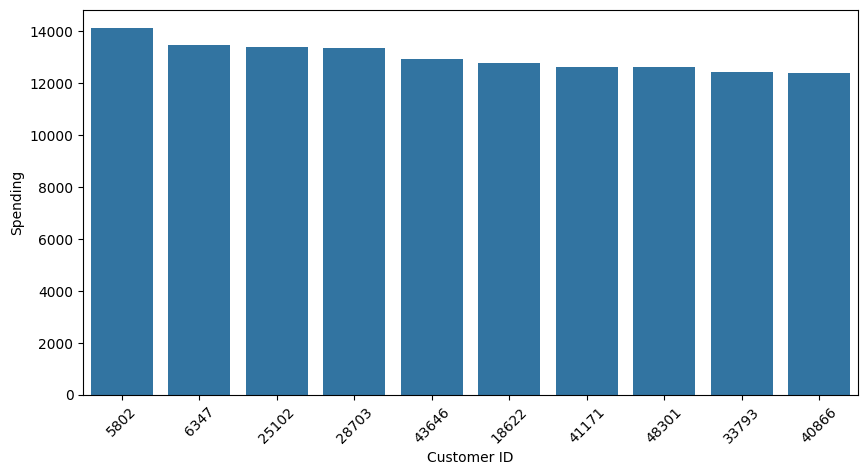

In [141]:
top = rfm.sort_values('Monetary',ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top.index.astype(str),y=top['Monetary'])
plt.xlabel('Customer ID')
plt.ylabel('Spending')
plt.xticks(rotation=45)
plt.show()

Monthly Sales Trend


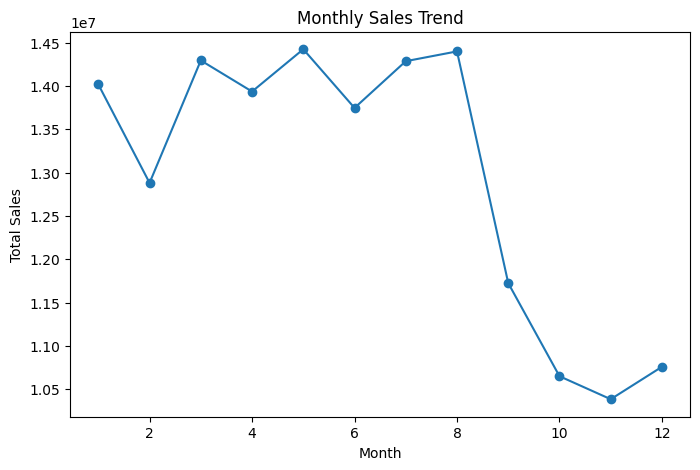

In [142]:
monthly=df.groupby('Month')['Total Purchase Amount'].sum()
plt.figure(figsize=(8,5))
monthly.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

Customer Segment


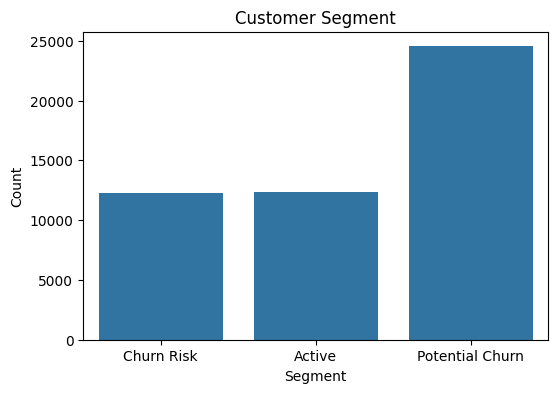

In [144]:
plt.figure(figsize=(6,4))
sns.countplot(x='Segment',data=rfm)
plt.title('Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

Revenue by Segment

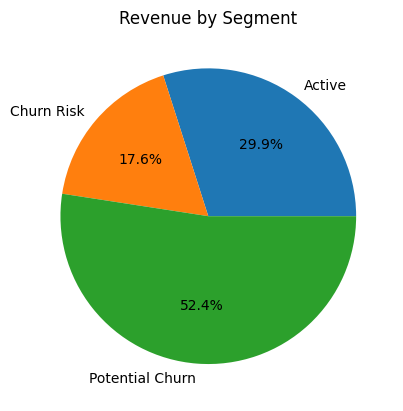

In [145]:
segment_rev=rfm.groupby('Segment')['Monetary'].sum()
segment_rev.plot(kind='pie',autopct='%1.1f%%')
plt.title('Revenue by Segment')
plt.ylabel('')
plt.show()

In [146]:
customer_month=df.groupby(['Customer ID','Month']).size().reset_index(name='Orders')
customer_month.head()


,Customer ID,Month,Orders
0,1,4,1
1,2,3,1
2,2,4,1
3,2,7,2
4,2,8,1


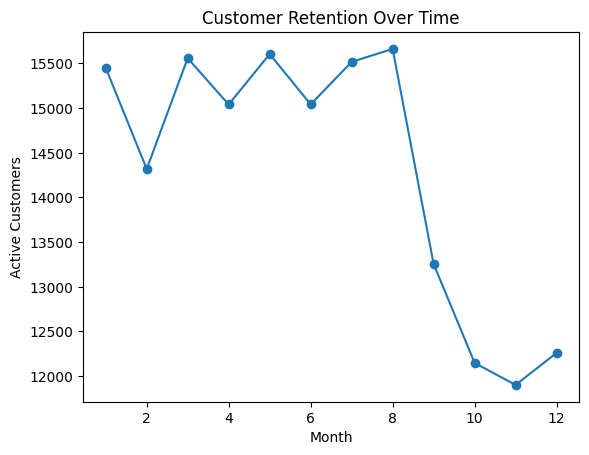

In [147]:
retention = customer_month.groupby('Month')['Customer ID'].nunique()
retention.plot(kind='line',marker='o')
plt.title('Customer Retention Over Time')
plt.xlabel('Month')
plt.ylabel('Active Customers')
plt.show()